In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data as get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st


from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

DATA_ROOT = 'DATAPATH'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

animal_ids = st.animal_labels(datapaths)

In [2]:
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
stability_neuron = []
for datapath in datapaths:
    stability_neuron.append(analysis.neuron_stability(datapath, 'Context1', ['0']+maps, remove_day_inactive=False))

c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
c:\Users\oles\Documents\code\Sylte_Kilias_et_al\analysis_code\analysis.py:297: RuntimeWarning: Mean of empty slice
  mean_correlations = np.nanmean(all_correlations, axis=1)
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
c:\Users\oles\Documents\code\Sylte_Kilias_et_al\analysis_code\analysis.py:297: RuntimeWarning: Mean of empty slice
  mean_correlations = np.nanmean(all_correlations, axis=1)
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not

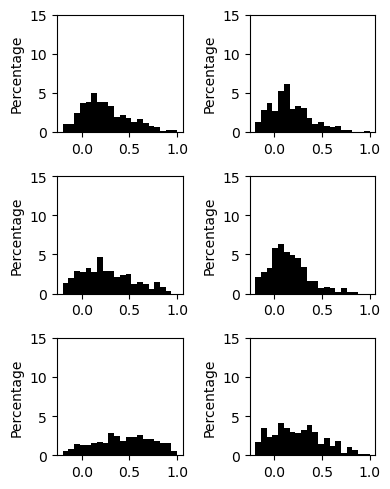

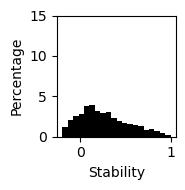

In [3]:
fig, axs = plt.subplots(3, 2, figsize=(4, 5))

for ax, stab in zip(axs.flatten(), stability_neuron):
    weights = np.ones_like(stab) / len(stab) * 100
    counts, bins, patches = ax.hist(stab, bins=20, range=(-0.2, 1), weights=weights, color='k')
    ax.set_ylim(0, 15)
    ax.set_ylabel('Percentage')

plt.tight_layout()
plt.show()

all_stability = np.concatenate(stability_neuron)
fig, ax = plt.subplots(figsize=(2, 2))
weights = np.ones_like(all_stability) / len(all_stability) * 100
counts, bins, patches = ax.hist(all_stability, bins=20, range=(-0.2, 1), weights=weights, color='k')
ax.set_ylim(0, 15)
ax.set_ylabel('Percentage')
ax.set_xlabel('Stability')
plt.tight_layout()
plt.show()

In [ ]:
above60 = [sum(stability > 0.7) / len(stability) * 100 for stability in stability_neuron]
fig, ax = plt.subplots(figsize=(2, 5))
ax.boxplot(above60)
ax.plot([1] * len(above60), above60, 'ro')
plt.show()

st.print_data(
    [np.array(above60)[:, None]],
    row_labels=animal_ids, col_labels=['% neurons with stability > 0.7'],
    condition_labels=[''], col_name='measure',
    title='Percentage of stable neurons (stability > 0.7) per animal')